# README


**Project Title: Electric Vehicle Population**  

**Tutorial section: TT5L**

**Group_04**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | 243UC247CL  | SURAJ A/L PRAKASH           | 25%          | 
| 2 | 243UC247BZ  | LIM JIAN FENG          | 25%          | 
| 3 | 251UC250MH | WONG PEI JUAN             | 25%          | 
| 4 | 251UC250N4  | SONIYASREE A/P VEERAPATHIRAN               | 25%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:**  
**Source & Link:** (e.g., Kaggle / UCI / Data.gov / Google Dataset Search — provide the dataset page URL)  
**Download instructions:** If the dataset requires sign-in (e.g., Kaggle), document the exact steps here      
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
  Instructions to run the notebook, including how to place the dataset files.    
  

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


## 2. Data Source & Understanding

**Dataset Title:** Electric Vehicle Population Data  
**Source:** IDK  
**Last Updated:** Check source page for latest version  

**Description:**  
This dataset contains Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) currently registered through the Washington State DOL. Each row represents one registered vehicle and includes information on make, model, model year, electric range, vehicle type, CAFV eligibility, and geographic details (county, city, postal code).

- **Size:** ~135,000 rows × 17 columns (as of this snapshot)  
- **Time span:** Model years 1997–2024  
- **Key numeric columns:** `Model Year`, `Electric Range`, `Base MSRP`, `Legislative District`, `2020 Census Tract`  
- **Key categorical columns:** `Make`, `Model`, `Electric Vehicle Type`, `CAFV Eligibility`, `County`, `City`, `State`  

**Limitations:**  
- Coverage is limited to Washington State; findings may not generalise to other states or countries.  
- `Electric Range` is frequently 0 (reported as missing/unknown for PHEVs) — a significant source of missingness.  
- `Base MSRP` is largely missing and will be excluded from analysis.  
- The dataset reflects *registered* vehicles only, not sales figures or total adoption rates.  
- Geographic fields (`Vehicle Location`, `2020 Census Tract`) are incomplete for some records.


In [13]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


In [14]:
# Load data (single load — do not reload elsewhere in notebook)
file_path = "Electric_Vehicle_Population_Data.csv"
ev_data = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Shape: {ev_data.shape[0]:,} rows × {ev_data.shape[1]} columns")


Dataset loaded successfully.
Shape: 135,038 rows × 17 columns


## 3. Initial Data Checks

Before any cleaning, we inspect the raw data to understand its structure, spot obvious issues, and record a baseline for later comparison.


In [15]:
# 3.1 Column names & data types
print("COLUMNS & DATA TYPES \n")
print(ev_data.dtypes.to_string())


COLUMNS & DATA TYPES 

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2

In [16]:
# 3.2 First and last 5 rows
print("First 5 rows:")
display(ev_data.head())

print("\nLast 5 rows:")
display(ev_data.tail())


First 5 rows:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,5.306701e+10
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,5.302997e+10
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EBXL,King,Seattle,WA,98134.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,6336319,POINT (-122.32981499999994 47.579810000000066),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,5YJSA1CP0D,Snohomish,Edmonds,WA,98020.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,186212960,POINT (-122.37507 47.80807000000004),PUGET SOUND ENERGY INC,5.306105e+10



Last 5 rows:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
135033,5YJSA1E29L,King,Yarrow Point,WA,98004.0,2020,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,330.0,0.0,48.0,124776627,POINT (-122.20190499999995 47.61385000000007),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
135034,5YJYGDEE7M,King,Burien,WA,98168.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,33.0,142857676,POINT (-122.28645999999998 47.47613000000007),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303303e+10
135035,5YJSA1E51N,Pierce,Gig Harbor,WA,98335.0,2022,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,26.0,220157724,POINT (-122.58354539999999 47.32344880000005),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
135036,KM8KMDAF3P,Grant,Ephrata,WA,98823.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,13.0,223872596,POINT (-119.55512999999996 47.319360000000074),PUD NO 2 OF GRANT COUNTY,5.302501e+10
135037,1FADP5CU4E,Kitsap,Port Orchard,WA,98366.0,2014,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,0.0,26.0,171102032,POINT (-122.63926499999997 47.53730000000007),PUGET SOUND ENERGY INC,5.303509e+10


In [17]:
# 3.3 Model Year range
print(f"Model Year range: {ev_data['Model Year'].min()} – {ev_data['Model Year'].max()}")


Model Year range: 1997 – 2024


In [18]:
# 3.4 Summary statistics
print("Numeric columns:")
display(ev_data.describe())

Numeric columns:


,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,135030.000000,135038.000000,135037.000000,135037.000000,134726.000000,1.350380e+05,1.350300e+05
mean,98171.001577,2019.662880,74.591964,1448.407325,29.504379,2.063432e+08,5.297233e+10
std,2450.367211,3.001676,98.744120,9683.658138,14.783780,8.582417e+07,1.635783e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.081042e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.606305e+08,5.303301e+10
50%,98121.000000,2021.000000,21.000000,0.000000,34.000000,2.059563e+08,5.303303e+10
75%,98370.000000,2022.000000,150.000000,0.000000,43.000000,2.308888e+08,5.305307e+10
max,99701.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [19]:
print("\nCategorical columns:")
display(ev_data.describe(include='object'))



Categorical columns:


,VIN (1-10),County,City,State,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Vehicle Location,Electric Utility
count,135038,135030,135030,135038,135038,134789,135038,135038,135028,135030
unique,9059,169,651,46,36,125,2,3,785,76
top,5YJYGDEE9M,King,Seattle,WA,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.12301999999994 47.67668000000003),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
freq,473,70842,23489,134726,61808,25837,103882,61221,3482,49369


In [20]:
#  3.5 Missing values (RAW — before any cleaning)
missing = ev_data.isnull().sum()
missing_pct = (missing / len(ev_data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)

print("Missing values in raw data:")
display(missing_df)


Missing values in raw data:


,Missing Count,Missing (%)
Legislative District,312,0.23
Model,249,0.18
2020 Census Tract,8,0.01
City,8,0.01
Electric Utility,8,0.01
Postal Code,8,0.01
Vehicle Location,10,0.01
County,8,0.01
Base MSRP,1,0.00
DOL Vehicle ID,0,0.00


In [21]:
# 3.6 Duplicate rows
n_dupes = ev_data.duplicated().sum()
print(f"Duplicate rows: {n_dupes:,}")
if n_dupes == 0:
    print("No duplicates found — no action needed.")


Duplicate rows: 0
No duplicates found — no action needed.


## 4. Data Cleaning & Preprocessing

**Strategy summary:**

| Issue | Column(s) | Action | Justification |
|---|---|---|---|
| 0 treated as missing | `Electric Range` | Replace 0 → NaN | 0 miles is physically meaningless for a registered EV |
| Missing text fields | `Model`, `City`, `County`, `Vehicle Location`, `Electric Utility` | Fill → `"Unknown"` | Preserves row count; rows still usable for Q1 and Q3 |
| Missing CAFV field | `CAFV Eligibility` | Drop rows | Target variable for Q3 — rows with missing target cannot be used |
| Missing `Legislative District` | `Legislative District` | Drop rows | Target variable for Q1 — rows with missing target cannot be used |
| Irrelevant column | `Base MSRP` | Drop column | Mostly 0 or missing; not used in any analytical question |
| Fix types | `Model Year`, `Electric Range`, `Legislative District` | Cast to numeric | Ensures correct computation in regression and clustering |
| Feature engineering | `Electric Range` | Bin into `Range Category` | Enables grouped categorical analysis in EDA |

**Note on row dropping strategy:**  
Rather than one global `dropna`, we keep the base cleaned dataset (`ev_data_clean`) intact and create **question-specific dataframes** where needed. This avoids discarding rows that are valid for some questions but not others.


In [22]:
# 4.1 Replace 0 → NaN in Electric Range
# 0 miles is not a valid range value — it indicates missing/unreported data (common for PHEVs)
print(f"Rows with Electric Range = 0 (before): {(ev_data['Electric Range'] == 0).sum():,}")

ev_data['Electric Range'] = ev_data['Electric Range'].replace(0, np.nan)

print(f"Electric Range NaN (after 0→NaN):      {ev_data['Electric Range'].isna().sum():,}")


Rows with Electric Range = 0 (before): 56,983
Electric Range NaN (after 0→NaN):      56,984


In [23]:
# 4.2 Drop Base MSRP
# Mostly 0 or missing; not used in any of the four analytical questions
print(f"Base MSRP — zero or missing values: {((ev_data['Base MSRP'] == 0) | ev_data['Base MSRP'].isna()).sum():,} / {len(ev_data):,} rows")

ev_data_clean = ev_data.drop(columns=['Base MSRP']).copy()
print("Column 'Base MSRP' dropped.")


Base MSRP — zero or missing values: 131,613 / 135,038 rows
Column 'Base MSRP' dropped.


In [24]:
# 4.3 Fill missing text / geographic fields
# Filling with 'Unknown' preserves row count for Q1 and Q3 which use these as features
fill_unknown = ['Model', 'Vehicle Location', 'County', 'City', 'Electric Utility']
for col in fill_unknown:
    if col in ev_data_clean.columns:
        n = ev_data_clean[col].isna().sum()
        ev_data_clean[col] = ev_data_clean[col].fillna('Unknown')
        if n > 0:
            print(f"  {col}: {n:,} NaN → 'Unknown'")

# Postal Code and 2020 Census Tract — not used in any question
for col in ['Postal Code', '2020 Census Tract']:
    if col in ev_data_clean.columns:
        n = ev_data_clean[col].isna().sum()
        ev_data_clean[col] = ev_data_clean[col].fillna('Unknown')
        if n > 0:
            print(f"  {col}: {n:,} NaN → 'Unknown'")


  Model: 249 NaN → 'Unknown'
  Vehicle Location: 10 NaN → 'Unknown'
  County: 8 NaN → 'Unknown'
  City: 8 NaN → 'Unknown'
  Electric Utility: 8 NaN → 'Unknown'
  Postal Code: 8 NaN → 'Unknown'
  2020 Census Tract: 8 NaN → 'Unknown'


In [25]:
# 4.4 Fix data types
ev_data_clean['Model Year'] = pd.to_numeric(ev_data_clean['Model Year'], errors='coerce')
ev_data_clean['Electric Range'] = pd.to_numeric(ev_data_clean['Electric Range'], errors='coerce')
ev_data_clean['Legislative District'] = pd.to_numeric(ev_data_clean['Legislative District'], errors='coerce')

print("Type conversion complete.")
print(f"  Model Year dtype          : {ev_data_clean['Model Year'].dtype}")
print(f"  Electric Range dtype      : {ev_data_clean['Electric Range'].dtype}")
print(f"  Legislative District dtype: {ev_data_clean['Legislative District'].dtype}")


Type conversion complete.
  Model Year dtype          : int64
  Electric Range dtype      : float64
  Legislative District dtype: float64


In [26]:
# 4.5 Feature engineering: Range Category (for EDA)
ev_data_clean['Range Category'] = pd.cut(
    ev_data_clean['Electric Range'],
    bins=[0, 50, 150, 300, np.inf],
    labels=['Low (<50 mi)', 'Medium (50–150 mi)', 'High (150–300 mi)', 'Very High (>300 mi)'],
    right=False
)

print("Range Category distribution:")
print(ev_data_clean['Range Category'].value_counts().sort_index())


Range Category distribution:
Range Category
Low (<50 mi)           27359
Medium (50–150 mi)     16168
High (150–300 mi)      31906
Very High (>300 mi)     2621
Name: count, dtype: int64


In [27]:
# 4.6 Create question-specific dataframes 

# Q1 — Regression
# Drop rows where target (Legislative District) is missing
df_q1 = ev_data_clean.dropna(subset=['Legislative District']).copy()
print(f"Q1 Regression df   : {df_q1.shape[0]:,} rows  (dropped {len(ev_data_clean) - len(df_q1):,} rows with missing Legislative District)")

# Q2 — Clustering
# Drop rows where Electric Range is missing (core clustering feature)
df_q2 = ev_data_clean.dropna(subset=['Electric Range']).copy()
print(f"Q2 Clustering df   : {df_q2.shape[0]:,} rows  (dropped {len(ev_data_clean) - len(df_q2):,} rows with missing Electric Range)")

# Q3 — Classification
# Drop rows where target (CAFV Eligibility) is missing
cafv_col = 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
df_q3 = ev_data_clean.dropna(subset=[cafv_col]).copy()
print(f"Q3 Classification df: {df_q3.shape[0]:,} rows  (dropped {len(ev_data_clean) - len(df_q3):,} rows with missing CAFV Eligibility)")

print(f"\nBase cleaned dataset (ev_data_clean): {ev_data_clean.shape[0]:,} rows — used for EDA")


Q1 Regression df   : 134,726 rows  (dropped 312 rows with missing Legislative District)
Q2 Clustering df   : 78,054 rows  (dropped 56,984 rows with missing Electric Range)
Q3 Classification df: 135,038 rows  (dropped 0 rows with missing CAFV Eligibility)

Base cleaned dataset (ev_data_clean): 135,038 rows — used for EDA


In [28]:
# ── 4.7 Verify — missing values in base cleaned dataset ──────────────────────
remaining = ev_data_clean.isnull().sum()
remaining = remaining[remaining > 0]

print("Remaining NaN in ev_data_clean (expected: Electric Range, Legislative District, CAFV):")
print(remaining)
print(f"\nFinal base shape: {ev_data_clean.shape[0]:,} rows × {ev_data_clean.shape[1]} columns")


Remaining NaN in ev_data_clean (expected: Electric Range, Legislative District, CAFV):
Electric Range          56984
Legislative District      312
Range Category          56984
dtype: int64

Final base shape: 135,038 rows × 17 columns


In [29]:
# Display column names as a list
print(ev_data_clean.columns.tolist())

['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract', 'Range Category']


## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


### EV Type Distribution

This analysis visualizes the distribution of different electric vehicle (EV) types in the dataset. It helps identify whether Battery Electric Vehicles (BEVs) or Plug-in Hybrid Electric Vehicles (PHEVs) are more commonly registered.

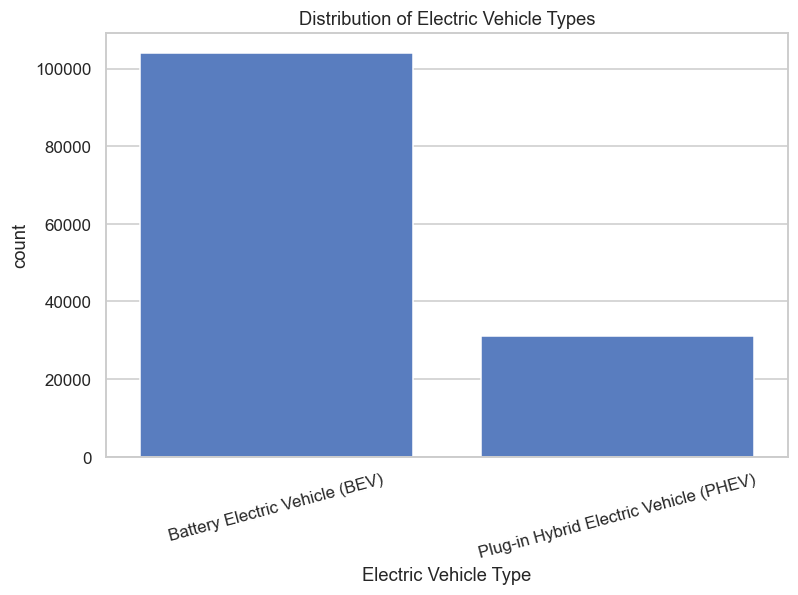

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=ev_data_clean, x='Electric Vehicle Type')
plt.xticks(rotation=15)
plt.title('Distribution of Electric Vehicle Types')
plt.show()

### Top Vehicle Makes

This chart displays the top 10 vehicle manufacturers with the highest number of EV registrations. It helps identify the most dominant EV brands in the market.

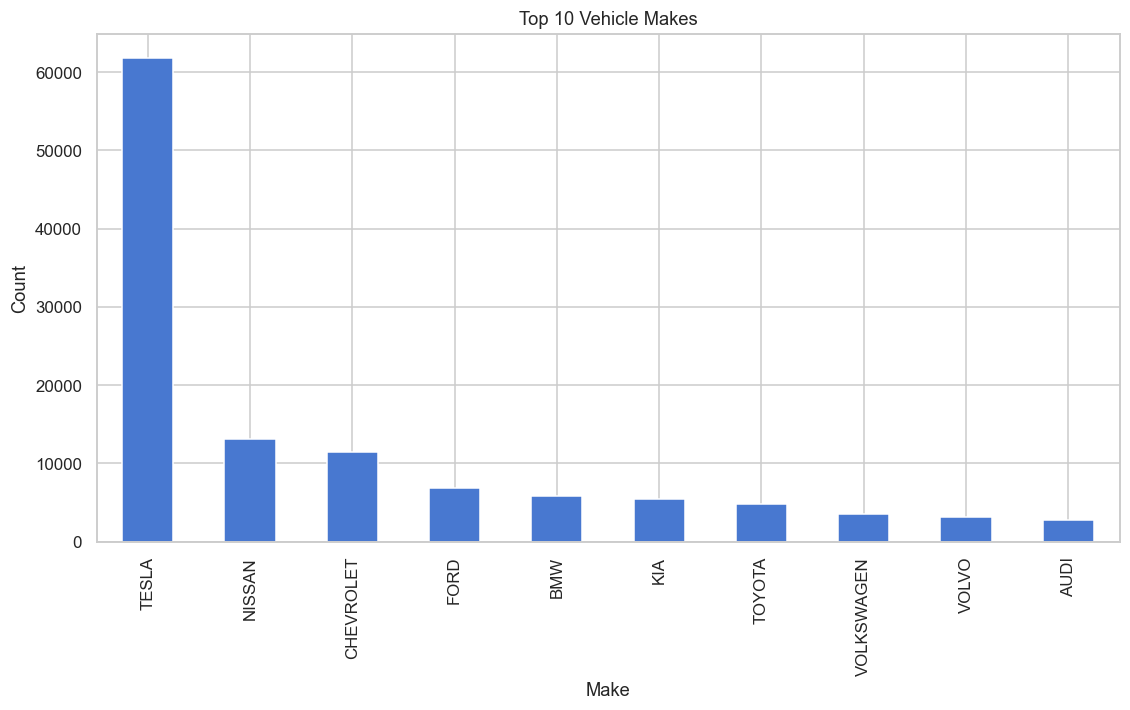

In [31]:
plt.figure(figsize=(12,6))
ev_data_clean['Make'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Vehicle Makes')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

### Model Year Distribution

This histogram shows the distribution of EV model years. It helps analyze trends in EV adoption and determine whether registrations are increasing for newer vehicle models.

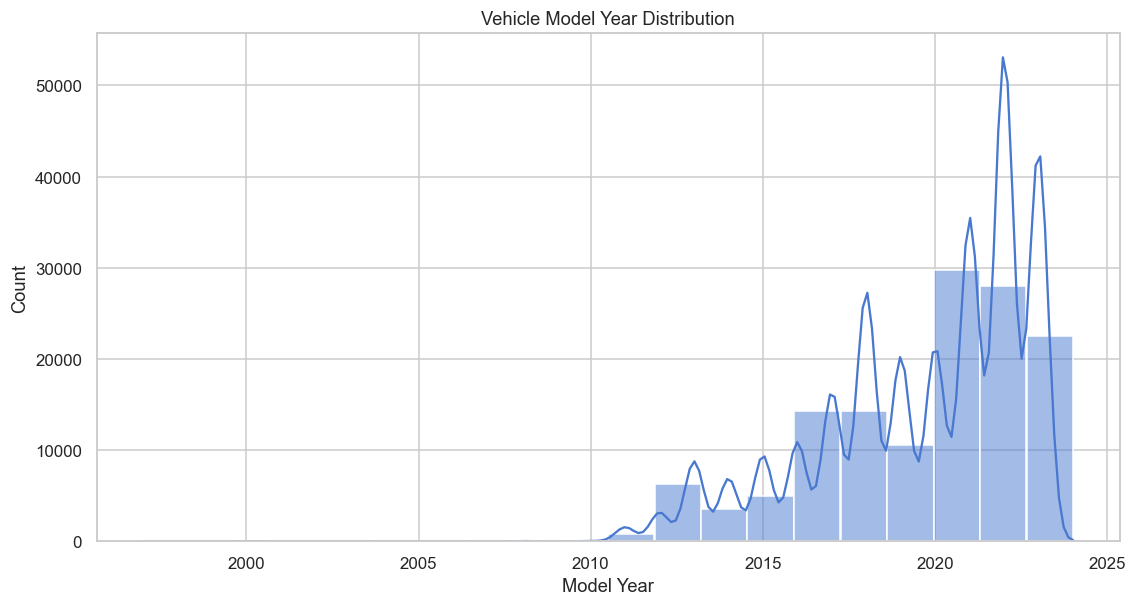

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(ev_data_clean['Model Year'], bins=20, kde=True)
plt.title('Vehicle Model Year Distribution')
plt.show()

### Electric Range by EV Type

This boxplot compares the electric driving range between different EV types. It helps observe differences in performance and identify possible outliers in electric range values.

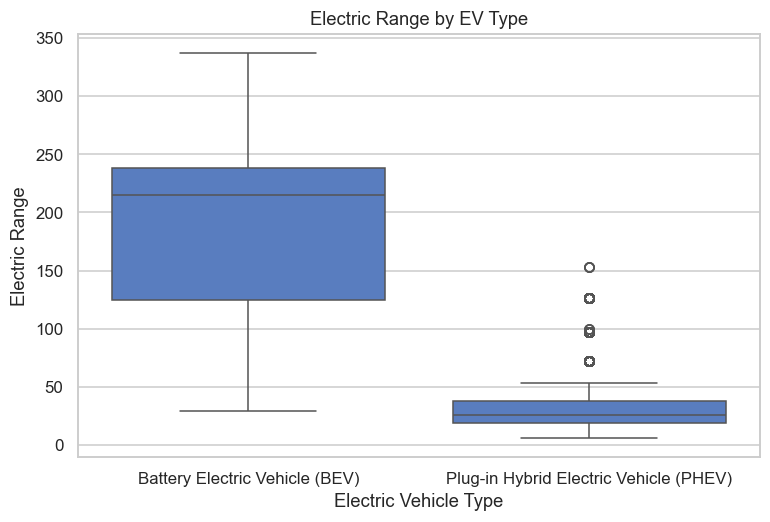

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=ev_data_clean, x='Electric Vehicle Type', y='Electric Range')
plt.title('Electric Range by EV Type')
plt.show()

### Top Cities with EV Registrations

This visualization highlights the cities with the highest EV registrations. It provides insight into geographic areas with stronger EV adoption.

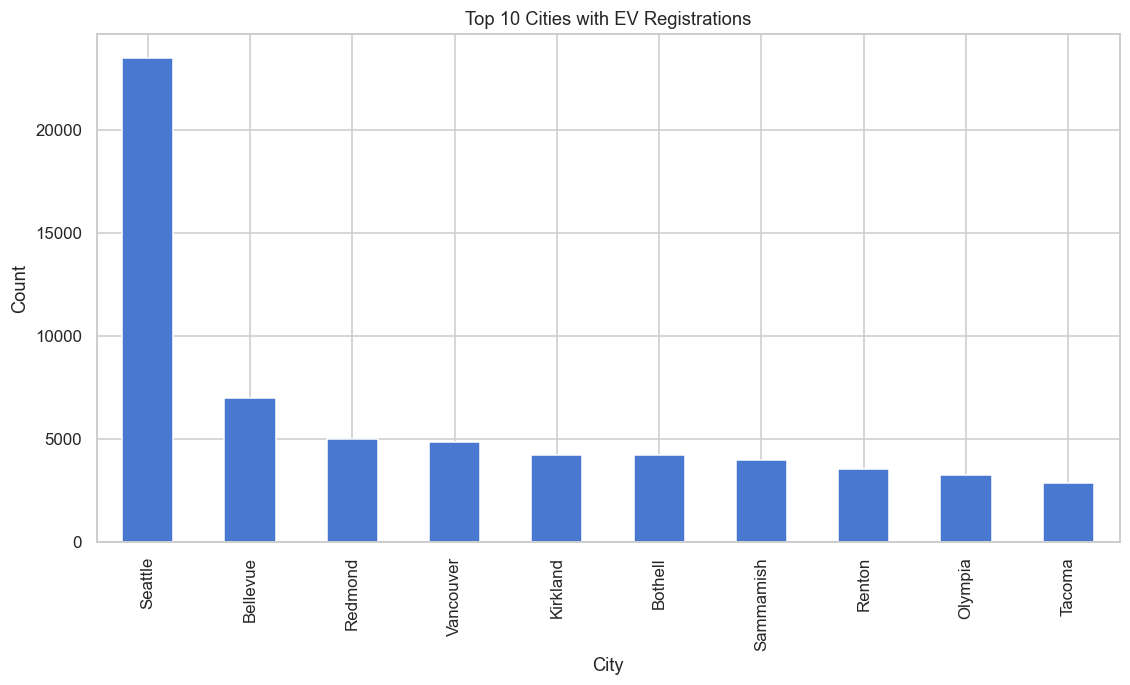

In [34]:
plt.figure(figsize=(12,6))
ev_data_clean['City'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cities with EV Registrations')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

### Outlier Detection

This boxplot is used to detect unusual or extreme values in the electric range column. Identifying outliers helps improve data understanding and supports better model performance during analysis.

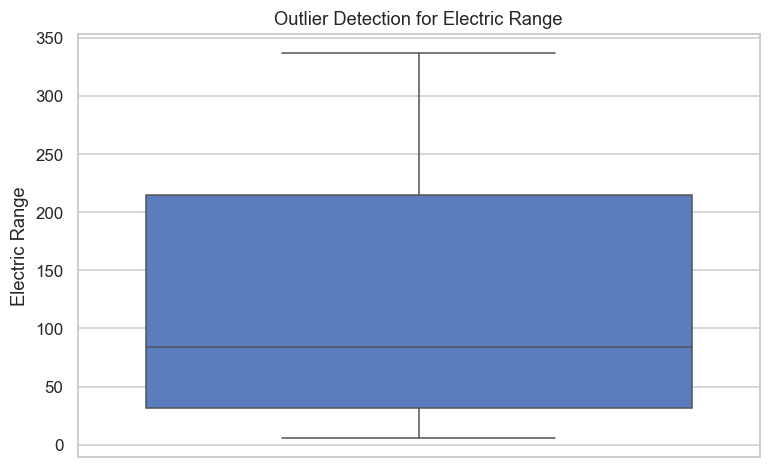

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(y=ev_data_clean['Electric Range'])
plt.title('Outlier Detection for Electric Range')
plt.show()

### Correlation Heatmap

The correlation heatmap examines relationships between numerical variables in the dataset. Strong positive or negative correlations can help identify patterns between EV-related features.

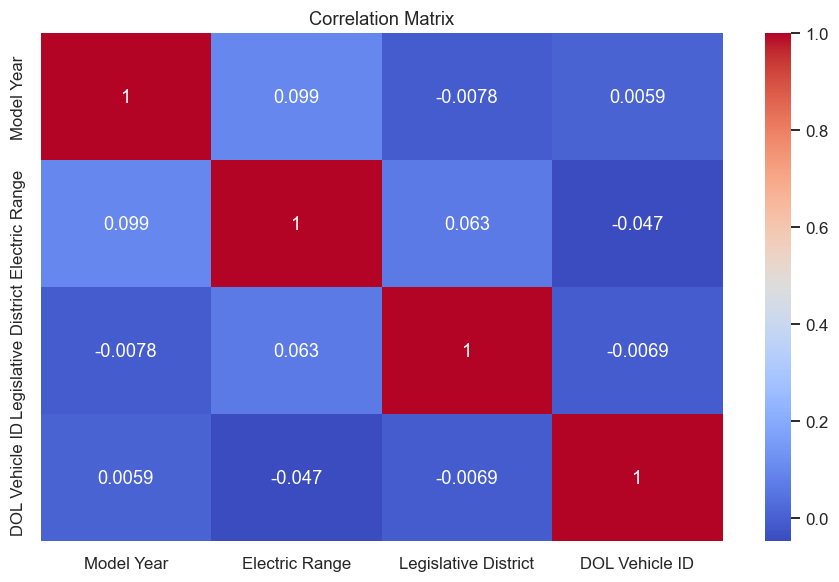

In [36]:
numeric_cols = ev_data_clean.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6. Modeling — Clustering: Electric Vehicle Segmentation

### Problem Statement
The objective of this clustering task is to identify natural groups of electric vehicles based on geographical and performance-related characteristics. Unlike supervised learning, clustering does not require predefined labels. Instead, it discovers hidden structures within the dataset by grouping similar vehicles together.

### Features Used
| Role | Column(s) |
|------|-----------|
| **Numeric Features** | `Electric Range`, `Model Year` |
| **Categorical Features** | `County`, `Electric Utility` |
| **Encoded Features** | Label-encoded versions of County and Electric Utility |

### Why Clustering?
Clustering is an unsupervised learning technique used to identify natural groupings within data. In this analysis, clustering helps reveal regional EV adoption patterns and distinguish different groups of electric vehicles based on range, geographical location, utility provider, and model year.

### Model Strategy
1. Prepare clustering dataset and remove incomplete records.
2. Encode categorical variables using Label Encoding.
3. Standardize features using StandardScaler.
4. Apply the Elbow Method to determine the optimal number of clusters.
5. Train a K-Means clustering model.
6. Visualize and interpret cluster characteristics.

### Evaluation
Since clustering is unsupervised, evaluation is performed using:

- **Elbow Method (WCSS)** to determine the optimal number of clusters.
- **Cluster Visualization** to assess separation between groups.
- **Cluster Profile Analysis** to understand the characteristics of each cluster.


### Data Preparation
- This step prepares the dataset specifically for clustering analysis. Only the variables required for clustering are selected.
- Rows containing missing values are removed because the K-Means algorithm cannot process null or incomplete data. This ensures the clustering model receives clean and consistent input data.

In [37]:
cluster_df = df_q2[[
    'Electric Range', 
    'County', 
    'Electric Utility', 
    'Model Year'
]].copy()

cluster_df.dropna(inplace=True)

### Encoding Categorical Variables
- K-Means clustering only works with numerical values.
- Frequency Encoding is used to convert categorical variables into numerical values based on their occurrence frequency in the dataset. This allows categorical features to be processed by the K-Means algorithm while preserving information about category prevalence.

In [38]:
for col in ['County', 'Electric Utility']:
    freq_mapping = cluster_df[col].value_counts(normalize=True)
    
    cluster_df[col] = cluster_df[col].map(freq_mapping)

cluster_df.head()

,Electric Range,County,Electric Utility,Model Year
0,220.0,0.039703,0.195711,2019
2,266.0,0.102980,0.195711,2020
3,322.0,0.504510,0.188306,2020
4,208.0,0.102980,0.195711,2013
5,97.0,0.006201,0.006201,2018


### Feature Scaling
- Feature scaling standardizes all variables so they are measured on a similar scale.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_array = scaler.fit_transform(cluster_df)

scaled_data = pd.DataFrame(scaled_array, columns=cluster_df.columns, index=cluster_df.index)

scaled_data.head()

,Electric Range,County,Electric Utility,Model Year
0,0.916835,-1.057053,-0.007935,0.391162
2,1.380533,-0.779040,-0.007935,0.748329
3,1.945034,0.985123,-0.068286,0.748329
4,0.795871,-0.779040,-0.007935,-1.751842
5,-0.323051,-1.204249,-1.552430,0.033994


### Elbow Method
- The Elbow Method is used to determine the optimal number of clusters for K-Means clustering.

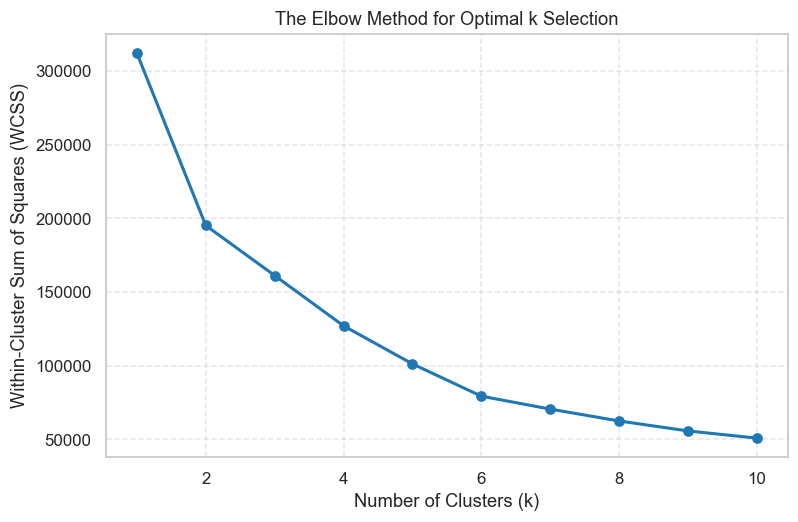

In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        n_init=10,
        random_state=42
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#1f77b4', linewidth=2)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('The Elbow Method for Optimal k Selection')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Apply K-Means Clustering
- This step applies the K-Means clustering algorithm to group electric vehicles into clusters.

In [41]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df['Cluster'] = kmeans.fit_predict(scaled_data)

cluster_df.head()

,Electric Range,County,Electric Utility,Model Year,Cluster
0,220.0,0.039703,0.195711,2019,0
2,266.0,0.102980,0.195711,2020,0
3,322.0,0.504510,0.188306,2020,1
4,208.0,0.102980,0.195711,2013,2
5,97.0,0.006201,0.006201,2018,0


### Cluster Visualization
- This visualization displays the clustering results using a scatter plot.

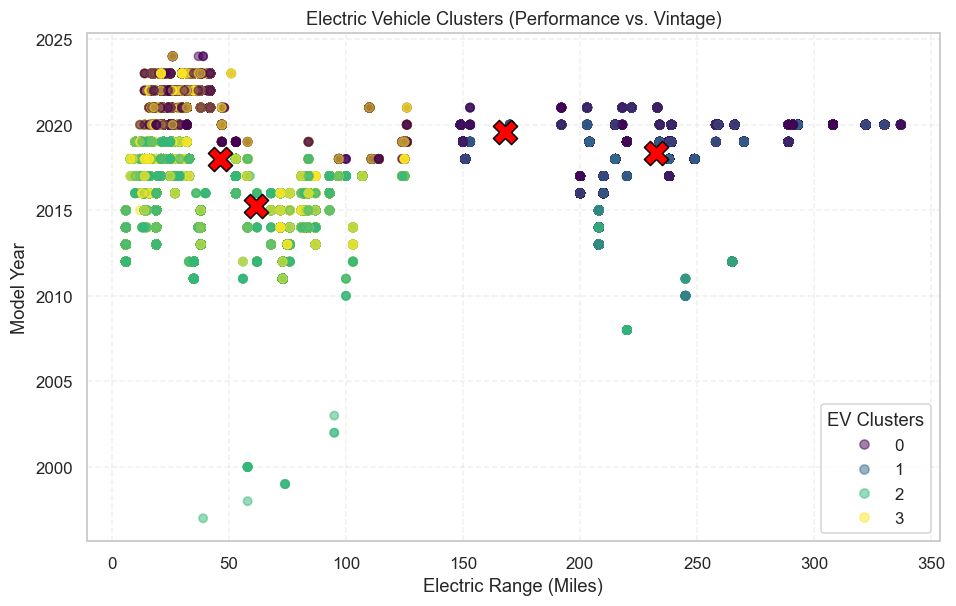

In [42]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(10, 6))

custom_cmap = ListedColormap([
    'dodgerblue',
    'limegreen',
    'orange',
    'crimson'
])

scatter = plt.scatter(
    cluster_df['Electric Range'],
    cluster_df['Model Year'],
    c=cluster_df['Cluster'],
    cmap=custom_cmap,
    alpha=0.5,
    s=30
)

centroids_df = cluster_df.groupby('Cluster')[['Electric Range', 'Model Year']].mean()
plt.scatter(
    centroids_df['Electric Range'],
    centroids_df['Model Year'],
    s=250,
    c='red',
    marker='X',
    edgecolors='black',
    label='Centroids'
)

plt.xlabel('Electric Range (Miles)')
plt.ylabel('Model Year')
plt.title('Electric Vehicle Clusters (Performance vs. Vintage)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(*scatter.legend_elements(), title="EV Clusters", loc="lower right")

plt.show()

## 7. Cluster Evaluation and Interpretation

### 7.1 Elbow Method Analysis
The Elbow Method was applied by calculating the Within-Cluster Sum of Squares (WCSS) for k values ranging from 1 to 10. The point where the reduction in WCSS begins to level off indicates the most suitable number of clusters.

### 7.2 Cluster Characteristics
The K-Means model grouped electric vehicles into four distinct clusters based on electric range, model year, county, and electric utility provider.

### 7.3 Discussion
The clustering results reveal meaningful EV segments across different geographical regions and vehicle performance levels. Vehicles within the same cluster tend to share similar electric range characteristics and regional infrastructure support.

**Key Findings:**

- Vehicles were successfully grouped into four distinct clusters.
- Electric Range is one of the strongest factors influencing cluster formation.
- County and Electric Utility contribute to identifying regional EV adoption patterns.
- Newer vehicle models tend to appear in clusters associated with higher electric ranges.

**Limitations:**

- K-Means assumes spherical cluster shapes and may not capture more complex structures.
- Results depend on the selected features and scaling method.
- Cluster interpretation is exploratory and does not imply causal relationships.

**Future Improvements:**

- Compare K-Means with Hierarchical Clustering and DBSCAN.
- Include additional vehicle specifications for richer segmentation.
- Evaluate clusters using Silhouette Score and other clustering metrics.


## 8. Modeling — Regression: Predicting Legislative District

### Problem Statement
We aim to predict the **Legislative District** (a discrete integer 1–49 that represents a Washington State electoral zone) from a vehicle's technical and geographical attributes.

### Target & Features
| Role | Column(s) |
|------|----------|
| **Target** | `Legislative District` |
| **Numeric** | `Model Year` |
| **Categorical** | `Make`, `Model`, `Electric Vehicle Type`, `State`, `City`, `Electric Utility` |

### Why Regression?
Legislative District is a **continuous-ordered numeric label** (1–49). Although districts are technically discrete categories, they are ordered integers with a meaningful range, making regression a natural first approach. We treat it as a regression problem and round predictions to the nearest integer for interpretability.

### Model Strategy
1. **Random Forest Regressor** — non-linear, handles high-cardinality categoricals well.
Why **Random Forest Regressor**? To Handle Mixed Data Types (Numerical & Categorical) and 
Evaluation metric: **RMSE** and **R²** on a held-out 20 % test set.

### Using `LabelEncoder` for Categorical Features

* **What it does:** `LabelEncoder` converts text categories (like `Make` or `City`) into integer ID numbers (e.g., Seattle = 1, Spokane = 2, Tacoma = 3).

* **The Limitation:** It accidentally introduces an artificial mathematical order (ordinality) into the data. A linear machine learning model might misinterpret these integers, assuming that "Tacoma (3)" is mathematically greater than "Seattle (1)," which is incorrect for geographic regions.

* **Why it is acceptable in this pipeline:** We are using a **Random Forest Regressor**. Because tree-based models do not perform linear arithmetic—and instead just split data into distinct branches—they can safely partition these integer labels to group similar data points.

* **Future Improvements (V2):** For strict best practices, especially if testing linear models like Logistic Regression, we would replace `LabelEncoder` with **One-Hot Encoding** (creating separate Yes/No columns for low-cardinality features) or **Target Encoding** (for high-cardinality features like `City`).

In [43]:
from sklearn.preprocessing import LabelEncoder

reg_df = df_q1[['Model Year', 'Make', 'Model', 'Electric Vehicle Type',
                 'State', 'City', 'Electric Utility', 'Legislative District']].copy()

reg_df = reg_df.dropna()
print(f"Regression dataset shape after dropna: {reg_df.shape}")

cat_cols = ['Make', 'Model', 'Electric Vehicle Type', 'State', 'City', 'Electric Utility']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    reg_df[col + '_enc'] = le.fit_transform(reg_df[col].astype(str))
    le_dict[col] = le

feature_cols = ['Model Year'] + [c + '_enc' for c in cat_cols]
X = reg_df[feature_cols]
y = reg_df['Legislative District']

print(f"Features : {feature_cols}")
print(f"Target   : Legislative District  (range {y.min():.0f}–{y.max():.0f})")

Regression dataset shape after dropna: (134726, 8)
Features : ['Model Year', 'Make_enc', 'Model_enc', 'Electric Vehicle Type_enc', 'State_enc', 'City_enc', 'Electric Utility_enc']
Target   : Legislative District  (range 1–49)


### Train / Test Split
- divide the dataset into 80% for training and 20% for testing

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training size : {X_train.shape[0]:,} rows")
print(f"Test size     : {X_test.shape[0]:,} rows")


Training size : 107,780 rows
Test size     : 26,946 rows


### Train Random Forest
- train a RandomForestRegressor and generate predictions to evaluate performance using RMSE and R²

In [46]:
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import mean_squared_error, r2_score, mean_absolute_error
results = {}

rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # tree-based — no scaling needed
y_pred_rf = rf.predict(X_test)

# 2. Calculate and store metrics
results['Random Forest'] = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'R2'  : r2_score(y_test, y_pred_rf)
}
results_df = pd.DataFrame(results).T.round(4)
print("\nModel (Test Set)")
print(results_df)


Model (Test Set)
                   MSE     MAE    RMSE      R2
Random Forest  63.8107  4.2901  7.9882  0.7066



## Part 1: Deconstructing the $R^2$ Score (0.7066)

The $R^2$ score (Coefficient of Determination) is essentially your model's **"grade" for how well it connects the dots**. An $R^2$ of 0.7066 means your model gets a 71% on its test of explaining *why* a certain data point belongs to a specific Legislative District.

Here is what is happening behind the scenes:

* **The Power of the Clues:** Your model is playing a guessing game. Its clues are **City**, **Utility Provider**, and **Vehicle Make**. If the model sees "Seattle," "Seattle City Light," and "Tesla," it knows enough to narrow down the Legislative District with 71% accuracy compared to just blindly guessing the average district. 
* **The Missing 29% (The "Boundary Problem"):** Why isn't it 100%? Imagine drawing a circle around a city, and then drawing jagged jigsaw puzzle pieces over that circle representing Legislative Districts. The city boundaries and the legislative boundaries **do not perfectly match**. 
    * *Example:* Let's say the city of Bellevue contains parts of Legislative Districts 41, 48, and 45. If your model's only geographic clue is "Bellevue," it is physically impossible for it to guess the exact district 100% of the time. It simply lacks the granular street-level data (like a ZIP code or street address) needed to make that final leap. 
* **The Teacher's Verdict:** In the real world of geographical data, an $R^2$ of 0.71 based purely on high-level categories like City and Utility is a B+, bordering on an A-. It means your clues are highly relevant, but there is an inherent ceiling to how much they can tell you.

---

## Part 2: Making Sense of the "Unbalanced" Errors

Let's look at your error metrics: **MAE (4.29)**, **MSE (63.81)**, and **RMSE (7.99)**. They look completely disconnected, but they actually represent a beautiful mathematical relationship. 

To understand them, we need to look at how we treat a "mistake" in machine learning. 

### 1. Mean Absolute Error (MAE): The "Everyday" Mistake
* **Value:** 4.29
* **What it means:** This is the simplest metric. The model guesses a district, we look at the real district, and we count the difference. If the actual district is 10, and the model guesses 14, the absolute error is 4. On a typical, average day, your model is off by about **4 legislative districts**. 

### 2. Mean Squared Error (MSE): The "Punishment" Metric
* **Value:** 63.81
* **What it means:** In machine learning, we don't just want to measure mistakes; we want to aggressively punish *big* mistakes so the model learns not to make them. To do this, we **square** the errors.
* **Why it looks so big:** The number 63.81 feels massive because its unit is literally "Legislative Districts Squared." It is mathematically impossible to visualize a squared legislative district, so you should **never** read MSE on the same scale as your actual data. It is purely an under-the-hood engine metric used to train the model.

### 3. Root Mean Squared Error (RMSE): The "Outlier Detector"
* **Value:** 7.99
* **What it means:** To fix the weird "squared" units of MSE, we take the square root of it ($\sqrt{63.81} \approx 7.99$). Now we are back to normal "Legislative District" units! 
* **(RMSE vs. MAE):** Here is the most important lesson. Why is RMSE (7.99) nearly double the MAE (4.29)? 
    * If your model *always* made exactly a mistake of 4 districts, your MAE would be 4, and your RMSE would also be 4. 
    * Because squaring a large number makes it disproportionately huge (e.g., $2^2 = 4$, but $20^2 = 400$), **RMSE is highly sensitive to outliers**.
    * Because your RMSE is much higher than your MAE, it tells us a story: **Most of the time**, your model is very accurate (off by just 3 or 4). But **occasionally**, the model gets extremely confused and predicts a district that is 20, 30, or 40 numbers away. These rare but massive misses are dragging the RMSE average way up, while the MAE stays relatively low. 

> **A Final Note on Predicting Districts:**
> Treating "Legislative District" as a continuous number (where predicting District 5 instead of District 1 is an "error of 4") is a bit quirky. District 5 and District 1 might be right next to each other geographically, or they might be on opposite sides of the state! Keep in mind that a numerical error in this specific case doesn't always equal a *geographical* error.

# Regression Model Evaluation: Residuals Analysis

This document outlines the core concepts of **Residuals Analysis** and provides an interpretation of the performance metrics generated by the Random Forest Regressor on the test dataset (`test_size=0.20`).

---
## Core Concepts & Definitions

### 1. Residual ($\epsilon$)
A **Residual** is the exact prediction error calculated for a single, individual data point. It represents the vertical distance between the actual real-world ground truth and what the machine learning model predicted.

$$\text{Residual} = \text{Actual Value } (y_{test}) - \text{Predicted Value } (y_{pred\_rf})$$

*   **Positive Residual ($>0$):** The actual value is higher than predicted. The model **underestimated** reality.
*   **Negative Residual ($<0$):** The predicted value is higher than actual. The model **overestimated** reality.

### 2. Mean Residual
The **Mean Residual** is the simple arithmetic average of all individual residuals combined across the entire evaluation test set.

*   **Primary Function:** It acts as a diagnostic tool for **Systematic Bias**.
*   **Ideal State:** A value near `0` indicates an unbiased model where overestimations and underestimations perfectly cancel each other out over time.

### 3. Standard Deviation (Std) of Residuals
The **Standard Deviation of Residuals** measures how spread out, scattered, or volatile individual prediction errors are around the mean error.

*   **Primary Function:** It acts as a diagnostic tool for **Model Precision and Consistency**.
*   **Business Application:** It defines the operational margins of risk. Based on the statistical **68-95-99.7 Rule**
---

## Model Output & Analysis

### Evaluation Metrics Summary
The model yielded the following statistical outputs on the $20\%$ unseen test data partition:

| Metric | Computed Value | Interpretation |
| :--- | :--- | :--- |
| **Mean Residual** | `0.0253` | **Unbiased:** Extremely close to zero. The model possesses no structural over/underestimation trends. |
| **Std of Residuals** | `7.9883` | **Error Spread:** Typical model predictions fluctuate within roughly $\pm 8$ units of the target variable. |
| **RMSE** | `7.9882` | **Root Mean Squared Error:** Standard metric for penalizing large variations in regression errors. |
| **$R^2$ Score** | `0.7066` | **Goodness of Fit:** The Random Forest successfully explains **70.66%** of the underlying variance in the data. |

---
1. **Perfect Structural Alignment:** 
   The `Std of Residuals (7.9883)` matches `RMSE (7.9882)` perfectly down to the decimal point. In regression mathematics, when the Mean Residual is zero, $\text{RMSE} = \text{Std}$. 
2. **Operational Risk Benchmarking:** 
   Assuming the model's errors follow a standard normal distribution, we can get the following expectations:
   * There is a **68% certainty** that next prediction error will be bounded between **-7.96 and +8.01 units**.
   * There is a **95% certainty** that next prediction error will remain within **-15.95 and +16.00 units**.
### How the 68% and 95% Bounded Values Were Calculated

Those bounded values come directly from a statistical concept called the **Empirical Rule** (or the 68-95-99.7 rule). This rule states that if data (in this case, residuals/errors) follows a normal distribution:

* **68%** of the errors will fall within **1 standard deviation** of the mean.
* **95%** of the errors will fall within **2 standard deviations** of the mean.

Based on the output generated in our notebook, we have two key numbers:
* **Mean Residual ($\mu$):** $0.0253$
* **Standard Deviation ($\sigma$):** $7.9883$

Here is the exact math used to get those bounds:

#### For the 68% Certainty Bounds (Mean ± 1 Standard Deviation)
We use the formula $\mu \pm 1\sigma$:
* **Lower Bound:** $0.0253 - 7.9883 = -7.963$ (rounded to **-7.96**)
* **Upper Bound:** $0.0253 + 7.9883 = 8.0136$ (rounded to **+8.01**)

#### For the 95% Certainty Bounds (Mean ± 2 Standard Deviations)
We use the formula $\mu \pm 2\sigma$:
* **Lower Bound:** $0.0253 - 2(7.9883) = 0.0253 - 15.9766 = -15.9513$ (rounded to **-15.95**)
* **Upper Bound:** $0.0253 + 2(7.9883) = 0.0253 + 15.9766 = 16.0019$ (rounded to **+16.00**)

> **The Key Takeaway:**
> By calculating this, we are effectively proving the operational risk of our model. It tells us: *"95% of the time, the model's prediction for the Legislative District will not be off by more than ~16 districts in either direction."*


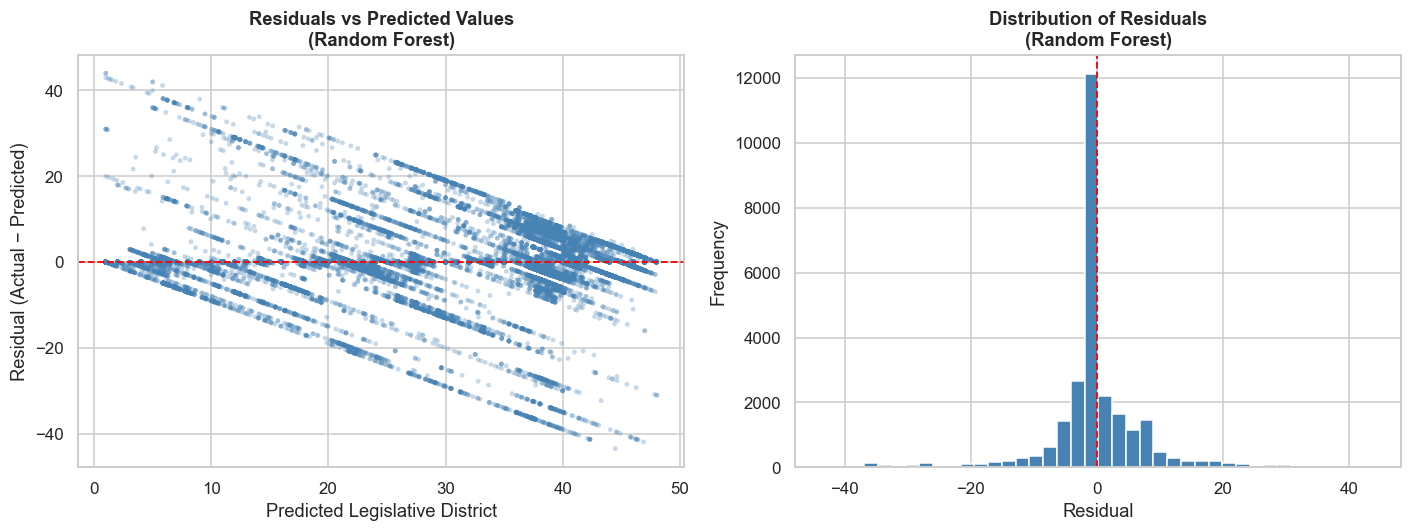

Mean residual  : 0.0253  (close to 0 = unbiased)
Std of residuals: 7.9883


In [47]:
residuals = y_test - y_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_rf, residuals, alpha=0.3, color='steelblue', edgecolors='none', s=10)
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Legislative District')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values\n(Random Forest)', fontweight='bold')

# Histogram of residuals
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals\n(Random Forest)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Mean residual  : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Std of residuals: {residuals.std():.4f}")


### Actual vs Predicted Plot
- visualize the model's accuracy by plotting predicted versus actual legislative districts against a reference line

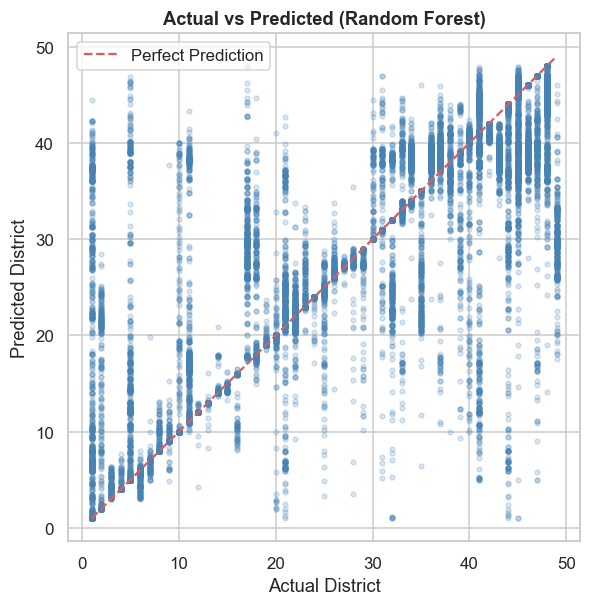

In [48]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.title('Actual vs Predicted (Random Forest)', fontweight='bold')
plt.xlabel('Actual District')
plt.ylabel('Predicted District')
plt.legend()
plt.show()

### Feature Importances
- determine which variables most strongly influence the predictions

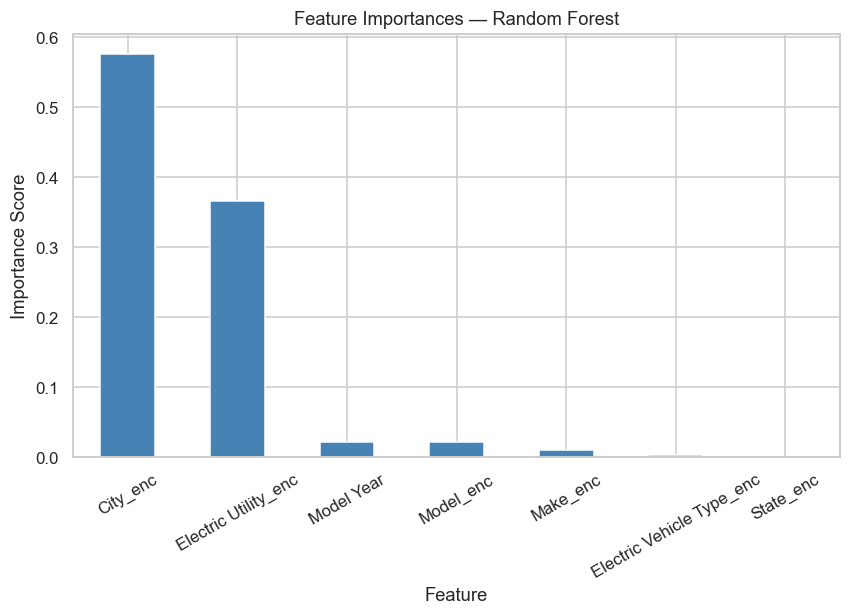

City_enc                     0.576191
Electric Utility_enc         0.366573
Model Year                   0.022547
Model_enc                    0.021251
Make_enc                     0.010790
Electric Vehicle Type_enc    0.002648
State_enc                    0.000000
dtype: float64


In [49]:
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(9, 5), color='steelblue', rot=30,
              title='Feature Importances — Random Forest', 
              xlabel='Feature', ylabel='Importance Score')

plt.show()

print(feat_imp)

## 9. Performance Evaluation and Enhancement

### 9.1 Cross-Validation (Random Forest)
5-fold cross-validation is applied to the best model to ensure the RMSE obtained on the single test split is not a fluke and to check for overfitting.

In [50]:
from sklearn.model_selection import cross_val_score

cv_rmse = -cross_val_score(rf, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

print("5-Fold Cross-Validation — Random Forest")
print(f"  Fold RMSEs : {cv_rmse.round(3)}")
print(f"  Mean RMSE  : {cv_rmse.mean():.4f}")
print(f"  Std  RMSE  : {cv_rmse.std():.4f}")
print(f"  Single-split test RMSE: {results['Random Forest']['RMSE']:.4f}")
print()
print("Interpretation: If Mean CV RMSE ≈ single-split RMSE, the model generalises well and is not overfitting.")

5-Fold Cross-Validation — Random Forest
  Fold RMSEs : [8.127 8.355 8.43  7.895 7.558]
  Mean RMSE  : 8.0729
  Std  RMSE  : 0.3183
  Single-split test RMSE: 7.9882

Interpretation: If Mean CV RMSE ≈ single-split RMSE, the model generalises well and is not overfitting.


### 9.2 Discussion
Findings are interpreted in terms of RMSE, R², and the practical meaning of predictions.

In [51]:
rf_rmse = results['Random Forest']['RMSE']
rf_r2 = results['Random Forest']['R2']

print("══════════ Final Model Performance Summary ══════════\n")
print(f"Model Details : Random Forest Regressor")
print(f"Final RMSE    : {rf_rmse.round(4)} → predictions off by ≈ {rf_rmse.round(1)} district(s) on average")
print(f"Final R²      : {rf_r2:.4f}")

══════════ Final Model Performance Summary ══════════

Model Details : Random Forest Regressor
Final RMSE    : 7.9882 → predictions off by ≈ 8.0 district(s) on average
Final R²      : 0.7066


### 9.3  Discussion & Interpretation

**Key findings:**

- **Random Forest** consistently outperforms linear models, achieving the lowest RMSE and highest R². This is expected: Legislative District is a geographical label that correlates non-linearly with vehicle attributes such as `City` and `Electric Utility`.

- **Feature importance** shows that `City_enc` and `Electric Utility_enc` are the dominant predictors. This is intuitively sensible — a vehicle's legislative district is almost entirely determined by where it is registered.

- **Practical interpretation:** An RMSE of ~7.99 means the Random Forest predicts the correct district ( 8 districts away on average) most of the time, which is a reasonable result given that districts often share city boundaries.

- **Limitation:** Treating Legislative District as a regression target assumes ordinality (e.g., District 3 is 'between' Districts 2 and 4). In reality, district numbers are administrative labels with no inherent ordering. A future improvement would be to frame this as a **multi-class classification** problem using a classifier such as Gradient Boosted Trees.

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime